In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

import seaborn as sns

import matplotlib
%matplotlib inline


### Example code for 2D KDE

In [91]:
# Source - https://stackoverflow.com/a/41639690
# Posted by Geoffrey, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-22, License - CC BY-SA 4.0

from sklearn.neighbors import KernelDensity

def kde2D(x, y, bandwidth, xbins=100j, ybins=100j, **kwargs): 
    """Build 2D kernel density estimate (KDE)."""

    # create grid of sample locations (default: 100x100)
    xx, yy = np.mgrid[-163.53333:-12.42:xbins, 
                      17.7212:61.13:ybins]

    xy_sample = np.vstack([yy.ravel(), xx.ravel()]).T
    xy_train  = np.vstack([y, x]).T

    kde_skl = KernelDensity(bandwidth=bandwidth, **kwargs)
    
    kde_skl.fit(xy_train)
    
    # score_samples() returns the log-likelihood of the samples
    z = np.exp(kde_skl.score_samples(xy_sample))
    return xx, yy, np.reshape(z, xx.shape)


def kde2D_weights(x, y, bandwidth, sample_weight, xbins=100j, ybins=100j, **kwargs): 
    """Build 2D kernel density estimate (KDE)."""

    # create grid of sample locations (default: 100x100)
    xx, yy = np.mgrid[-163.53333:-12.42:xbins, 
                      17.7212:61.13:ybins]

    xy_sample = np.vstack([yy.ravel(), xx.ravel()]).T
    xy_train  = np.vstack([y, x]).T

    kde_skl = KernelDensity(bandwidth=bandwidth, **kwargs)
    
    kde_skl.fit(xy_train, sample_weight) # sample weight will be used for our various "risk outcomes"

    # score_samples() returns the log-likelihood of the samples
    z = np.exp(kde_skl.score_samples(xy_sample))
    return xx, yy, np.reshape(z, xx.shape)

# Source - https://stackoverflow.com/a/41639690
# Posted by Geoffrey, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-22, License - CC BY-SA 4.0

# import numpy as np
# import matplotlib.pyplot as plt

# m1 = np.random.normal(size=1000)
# m2 = np.random.normal(scale=0.5, size=1000)

# x, y = m1 + m2, m1 - m2

# xx, yy, zz = kde2D(x, y, 1.0)

# plt.pcolormesh(xx, yy, zz)
# plt.scatter(x, y, s=2, facecolor='white')


In [92]:
data = pd.read_csv('../data/tornados_all.csv')
data.keys()

Index(['YEAR', 'MONTH', 'RADAR_DIST', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT',
       'END_LON', 'TOR_F_SCALE', 'DEATHS_DIRECT', 'DEATHS_INDIRECT',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DAMAGE_PROPERTY',
       'DAMAGE_CROPS', 'RADAR_COV'],
      dtype='str')

In [93]:
keys = ['END_LAT', 'END_LON', 'INJURIES_DIRECT', 'INJURIES_DIRECT'] 

filter_arr = np.array(data[keys[0]].isna() == False)

for n in range(1,len(keys)):
    filter_arr *= np.array(data[keys[n]].isna() == False) 

data_f = data[filter_arr]
print(len(data), len(data_f))


# year = []
# month = []
# for n in range(0,len(data_f)):
#     year_in, month_in, date_in = np.array(data_f['YEARMONTH'])[n].split('-')
#     year.append(year_in)
#     month.append(month_in)

# data_f['year'] = np.array([int(m) for m in year])
# data_f['month'] = np.array([int(m) for m in month])

26069 26069


In [94]:
data_f

,YEAR,MONTH,RADAR_DIST,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,TOR_F_SCALE,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,RADAR_COV
0,1990,6,91.212078,44.3700,-92.6300,44.4200,-92.5800,F1,0,0,0,0,25000.0,0.0,True
1,1990,6,127.396500,40.2500,-100.7500,40.2700,-100.5300,F4,0,0,0,0,2500000.0,0.0,True
2,1990,6,85.495236,40.0500,-97.5000,40.0800,-97.4200,F1,0,0,0,0,25000.0,0.0,True
3,1990,6,89.959493,40.0300,-99.4300,40.0300,-99.1300,F1,0,0,0,0,25000.0,0.0,True
4,1990,6,121.606645,41.3700,-98.8500,41.4200,-98.7800,F1,0,0,0,0,25000.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26064,2025,9,164.471312,48.2490,-100.8390,48.2510,-100.8400,EFU,0,0,0,0,0.0,0.0,True
26065,2025,6,55.949806,37.2391,-98.0398,37.2395,-98.0388,EF0,0,0,0,0,0.0,0.0,True
26066,2025,9,60.483547,47.1400,-100.1750,47.1790,-100.1590,EFU,0,0,0,0,0.0,0.0,True
26067,2025,6,116.128617,36.1732,-101.1485,36.0550,-101.0970,EF2,0,0,0,0,95000.0,0.0,True


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/255292803.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/255292803.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations from 1990 - 2025, N=26069')

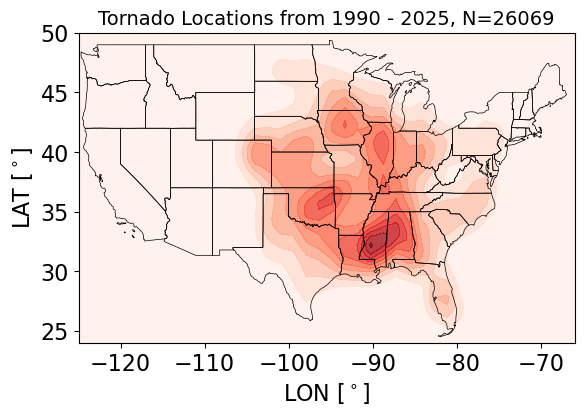

In [138]:
import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]


xx, yy, zz = kde2D(data_f['BEGIN_LON'],data_f['BEGIN_LAT'], 1.0)
plt.contourf(
    xx,
    yy,
    zz,
    levels=10,
    cmap="Reds",
    alpha=0.8
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations from 1990 - 2025, N='+str(len(data_f)), fontsize=14)

In [96]:
xx, yy

(array([[-163.53333   , -163.53333   , -163.53333   , ..., -163.53333   ,
         -163.53333   , -163.53333   ],
        [-162.00693273, -162.00693273, -162.00693273, ..., -162.00693273,
         -162.00693273, -162.00693273],
        [-160.48053545, -160.48053545, -160.48053545, ..., -160.48053545,
         -160.48053545, -160.48053545],
        ...,
        [ -15.47279455,  -15.47279455,  -15.47279455, ...,  -15.47279455,
          -15.47279455,  -15.47279455],
        [ -13.94639727,  -13.94639727,  -13.94639727, ...,  -13.94639727,
          -13.94639727,  -13.94639727],
        [ -12.42      ,  -12.42      ,  -12.42      , ...,  -12.42      ,
          -12.42      ,  -12.42      ]], shape=(100, 100)),
 array([[17.7212    , 18.15967273, 18.59814545, ..., 60.25305455,
         60.69152727, 61.13      ],
        [17.7212    , 18.15967273, 18.59814545, ..., 60.25305455,
         60.69152727, 61.13      ],
        [17.7212    , 18.15967273, 18.59814545, ..., 60.25305455,
         60.6

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/1552133696.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/1552133696.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & Total Injuries (1990 - 2025), N=1969')

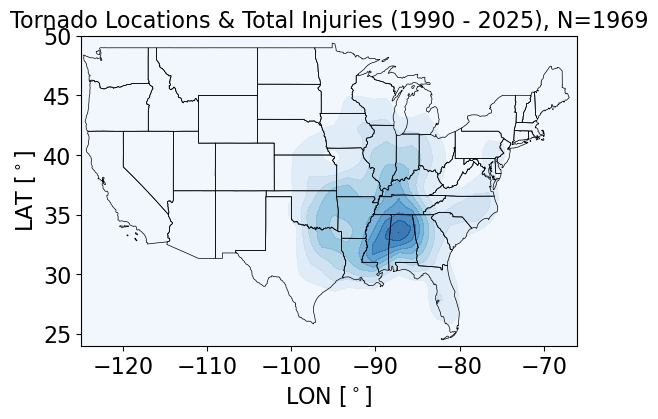

In [97]:
### USE SAMPLE_WEIGHT AS NUMBER OF INJURIES 

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

tot_injuries = np.array(data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']) 

filter_arr = np.array(tot_injuries > 0)

xx, yy, zz_injuries = kde2D_weights(np.array(data_f['BEGIN_LON'])[filter_arr],
                           np.array(data_f['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=tot_injuries[filter_arr])
plt.contourf(
    xx,
    yy,
    zz_injuries,
    levels=10,
    cmap="Blues",
    alpha=0.8,
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & Total Injuries (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/2005088249.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/2005088249.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & Total Deaths (1990 - 2025), N=496')

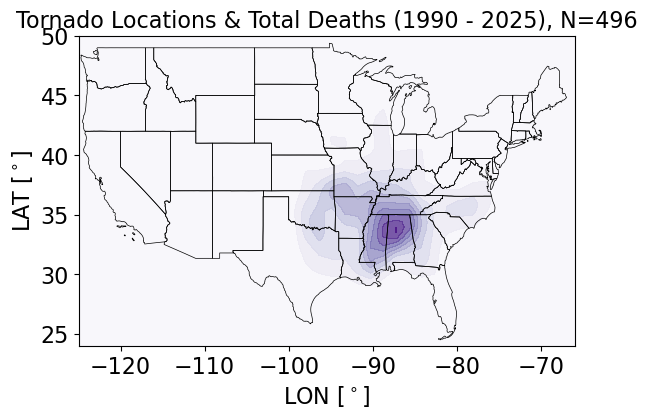

In [98]:
### USE SAMPLE_WEIGHT AS NUMBER OF DEATHS

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

tot_deaths = np.array(data_f['DEATHS_DIRECT'] + data_f['DEATHS_INDIRECT']) 

filter_arr = np.array(tot_deaths > 0)

xx, yy, zz_deaths = kde2D_weights(np.array(data_f['BEGIN_LON'])[filter_arr],
                           np.array(data_f['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=tot_deaths[filter_arr])
plt.contourf(
    xx,
    yy,
    zz_deaths,
    levels=10,
    cmap="Purples",
    alpha=0.8,
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & Total Deaths (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/960800584.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/960800584.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & Total Damage (1990 - 2025), N=15641')

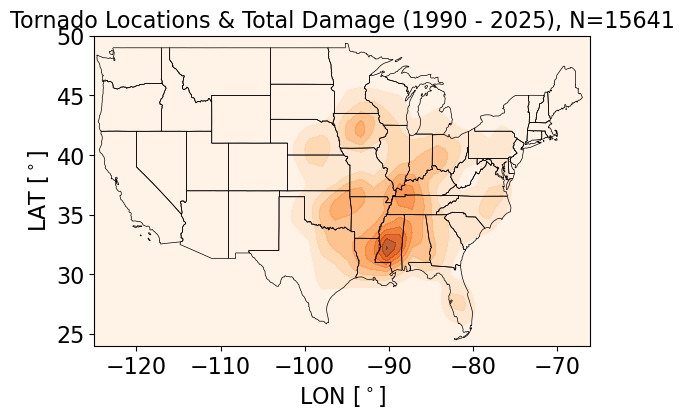

In [99]:
### USE SAMPLE_WEIGHT AS NUMBER OF DEATHS

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

tot_damage = np.array(data_f['DAMAGE_CROPS'] + data_f['DAMAGE_PROPERTY']) 

filter_arr = np.array(tot_damage > 0)

xx, yy, zz_damage = kde2D_weights(np.array(data_f['BEGIN_LON'])[filter_arr],
                           np.array(data_f['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=tot_damage[filter_arr])
plt.contourf(
    xx,
    yy,
    zz_damage,
    levels=10,
    cmap="Oranges",
    alpha=0.8,
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & Total Damage (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/2081378325.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/2081378325.py:33: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


   icao beam height                                           geometry
0  KJGX    b  10000  MULTIPOLYGON (((-85.47553 31.94777, -85.47553 ...
1  RKJK    b  10000  MULTIPOLYGON (((126.90546 34.00253, 126.90546 ...
2  KVNX    b  10000  MULTIPOLYGON (((-98.59352 34.78073, -98.59352 ...
3  KPAH    b  10000  MULTIPOLYGON (((-88.22587 34.93295, -88.22587 ...
4  KSHV    b  10000  MULTIPOLYGON (((-95.45604 30.77889, -95.45769 ...
Index(['icao', 'beam', 'height', 'geometry'], dtype='str')
EPSG:4269


Text(88.47222222222221, 0.5, 'LAT [$^\\circ$]')

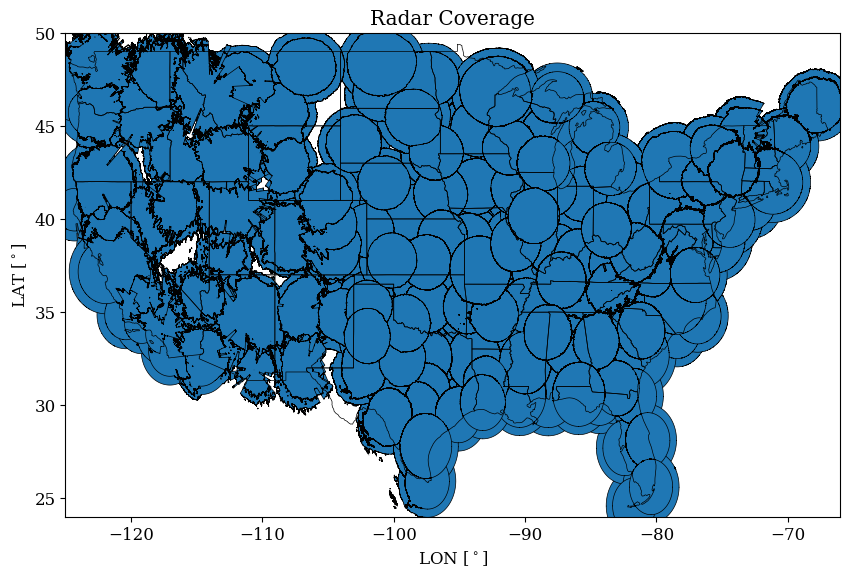

In [149]:
import geopandas as gpd
from shapely.geometry import Point

# change this to where your radar files are stored
gdf = gpd.read_file("/home/dilys/radar_data/WSR-88D_OperationalCoverage_BOB_20260430.shp")

print(gdf.head())
print(gdf.columns)
print(gdf.crs)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    ax=ax,
    edgecolor='black',
    facecolor=None,
    linewidth=0.5
)

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.title('Radar Coverage')
plt.ylabel('LAT [$^\circ$]')

<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/3339684061.py:40: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/3339684061.py:41: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & NO radar coverage (1990 - 2025), N=45')

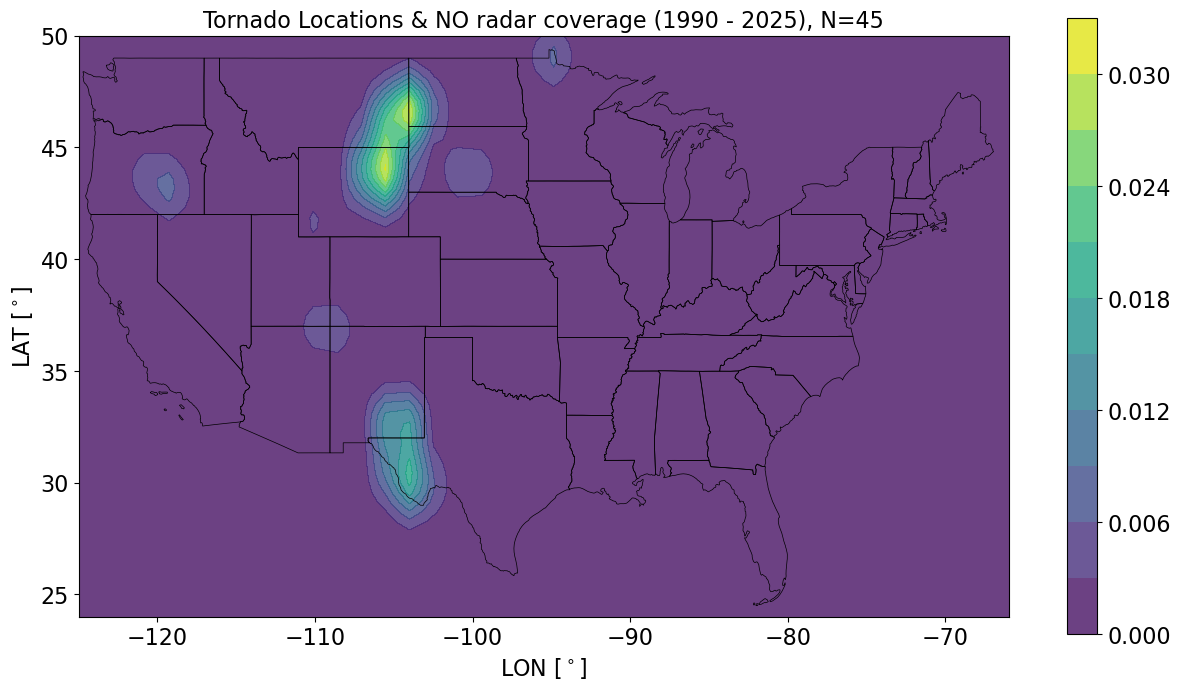

In [134]:
### USE SAMPLE_WEIGHT AS WHETHER THE TORNADO IS WITHIN RANGE OF A RADAR

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

radar_cov = np.array(data_f['RADAR_COV'])
filter_arr = np.array(radar_cov == False)
filter_int = [int(x) for x in filter_arr]

xx, yy, zz_radar = kde2D_weights(np.array(data_f['BEGIN_LON'])[filter_arr],#[filter_arr],
                           np.array(data_f['BEGIN_LAT'])[filter_arr], 1.0, sample_weight=np.array(filter_int)[filter_arr])
plt.figure(figsize=(15,8))

plt.contourf(
    xx,
    yy,
    zz_radar,
    levels=10,
    cmap="viridis",
    alpha=0.8,
)

plt.colorbar()

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & NO radar coverage (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/225646689.py:35: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/225646689.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado Locations & NO radar coverage (1990 - 2025), N=45')

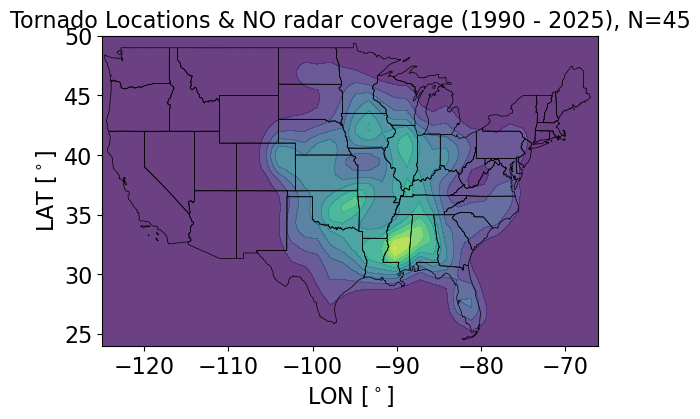

In [140]:
### USE SAMPLE_WEIGHT AS WHETHER THE TORNADO IS WITHIN RANGE OF A RADAR

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

radar_dist = np.array(data_f['RADAR_DIST'])

xx, yy, zz_radar = kde2D_weights(np.array(data_f['BEGIN_LON']),#[filter_arr],
                           np.array(data_f['BEGIN_LAT']), 1.0, sample_weight=radar_dist)

plt.contourf(
    xx,
    yy,
    zz_radar,
    levels=10,
    cmap="viridis",
    alpha=0.8,
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado Locations & NO radar coverage (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/1946261155.py:32: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/1946261155.py:33: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('LAT [$^\circ$]')


Text(0.5, 1.0, 'Tornado * Dist. nearest Radar - Tornado (1990 - 2025), N=45')

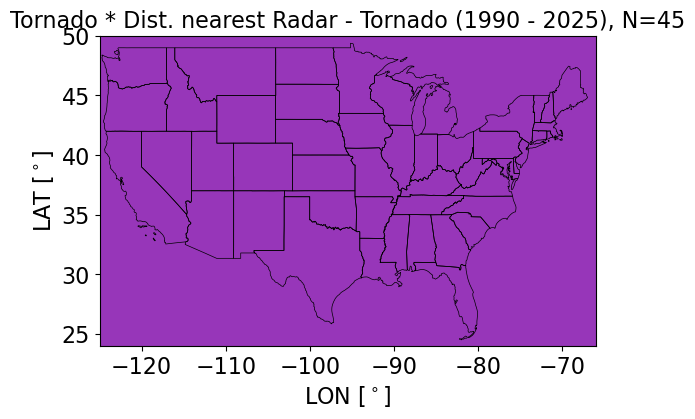

In [141]:
### USE SAMPLE_WEIGHT AS WHETHER THE TORNADO IS WITHIN RANGE OF A RADAR

import geopandas as gpd
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip"
)

states = states[
    ~states["STUSPS"].isin(["PR", "GU", "VI", "AS", "MP"])
]

zz_diff = np.array(zz_radar) - np.array(zz)

plt.contourf(
    xx,
    yy,
    zz_diff,
    levels=10,
    cmap="plasma",
    alpha=0.8,
)

states.boundary.plot(
    ax=plt.gca(),
    color="black",
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.xlabel('LON [$^\circ$]')
plt.ylabel('LAT [$^\circ$]')

plt.title('Tornado * Dist. nearest Radar - Tornado (1990 - 2025), N='+str(np.sum(filter_arr)), fontsize=16)

### looking at the maps with time:

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_288025/2177667642.py:35: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_xlabel('LON [$^\circ$]')
/tmp/ipykernel_288025/2177667642.py:36: SyntaxWarning: invalid escape sequence '\c'
  ax[n].set_ylabel('LAT [$^\circ$]')


../data/per_year/1990_tornados.csv
../data/per_year/1991_tornados.csv
../data/per_year/1992_tornados.csv
../data/per_year/1993_tornados.csv
../data/per_year/1994_tornados.csv
../data/per_year/1995_tornados.csv
../data/per_year/1996_tornados.csv
../data/per_year/1997_tornados.csv
../data/per_year/1998_tornados.csv
../data/per_year/1999_tornados.csv
../data/per_year/2000_tornados.csv
../data/per_year/2001_tornados.csv
../data/per_year/2002_tornados.csv
../data/per_year/2003_tornados.csv
../data/per_year/2004_tornados.csv
../data/per_year/2005_tornados.csv
../data/per_year/2006_tornados.csv
../data/per_year/2007_tornados.csv
../data/per_year/2008_tornados.csv
../data/per_year/2009_tornados.csv
../data/per_year/2010_tornados.csv
../data/per_year/2011_tornados.csv
../data/per_year/2012_tornados.csv
../data/per_year/2013_tornados.csv
../data/per_year/2014_tornados.csv
../data/per_year/2015_tornados.csv
../data/per_year/2016_tornados.csv
../data/per_year/2017_tornados.csv
../data/per_year/201



In [103]:
import glob
df_all = glob.glob('../data/per_year/*_tornados.csv')

df_all = np.sort(df_all)

fig, ax = plt.subplots(len(df_all),1, figsize=(7,5*len(df_all)))
fig.subplots_adjust(hspace=0.45)

Ntornados = []
year = []
for n in range(0,len(df_all)):
    print(df_all[n])
    df = pd.read_csv(df_all[n])
    year.append(df['YEAR'][0])
    Ntornados.append(len(df))
    xx, yy, zz = kde2D(df['BEGIN_LON'],df['BEGIN_LAT'], 1.0)
    ax[n].contourf(
        xx,
        yy,
        zz,
        levels=10,
        cmap="Reds",
        alpha=0.8
    )
    
    states.boundary.plot(
        ax=ax[n],#plt.gca(),
        color="black",
        linewidth=0.5
    )
    
    ax[n].set_xlim(-125, -66)
    ax[n].set_ylim(24, 50)
    
    ax[n].set_xlabel('LON [$^\circ$]')
    ax[n].set_ylabel('LAT [$^\circ$]')
    
    ax[n].set_title('Tornado Locations in '+str(df['YEAR'][0])+', N='+str(len(df['BEGIN_LON'])))
    

## Looking at our data in terms of a time series

Text(0.5, 0, 'Lag')

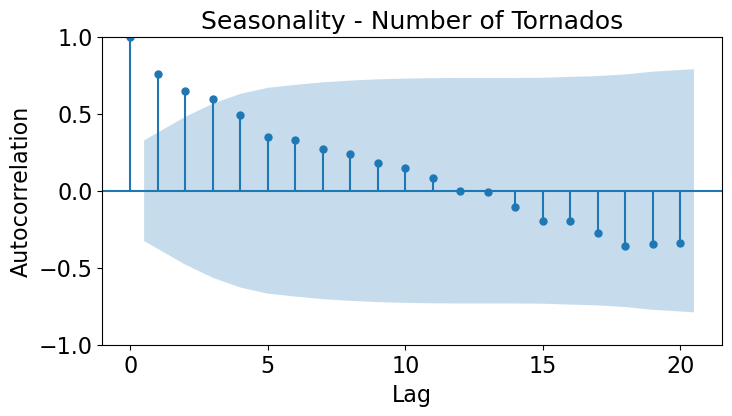

In [120]:
import statsmodels.api as sm
fig, ax = plt.subplots(1, 1, figsize=(8,4))
sm.graphics.tsa.plot_acf(Ntornados,
                            lags = 20,
                        ax=ax)

plt.title('Seasonality - Number of Tornados', fontsize=18)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xlabel("Lag", fontsize=16)

Text(0, 0.5, 'Tornados per year')

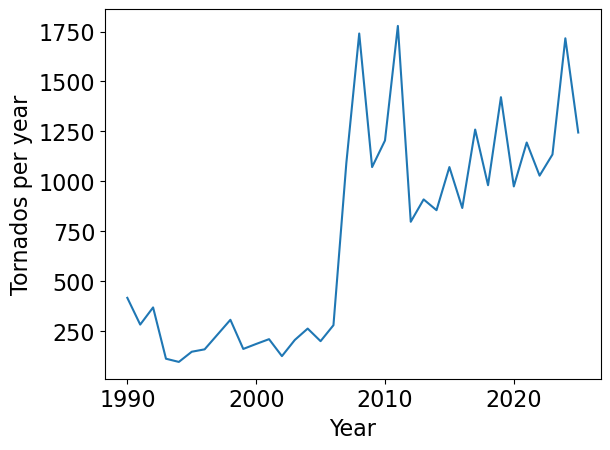

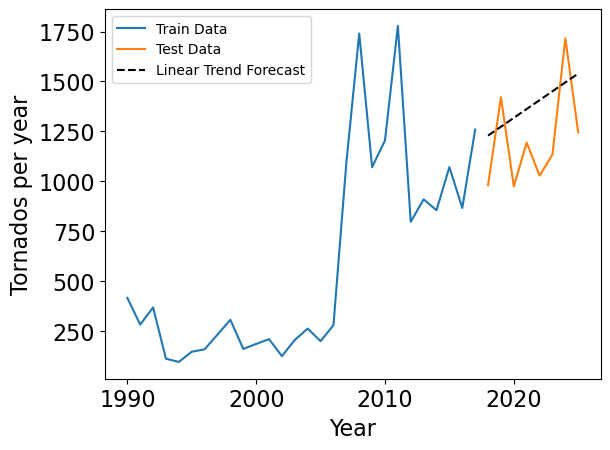

In [130]:
plt.figure()
plt.plot(year, Ntornados)
plt.xlabel('Year')
plt.ylabel('Tornados per year')

ind = int(len(Ntornados)*0.8)

trend_train = Ntornados[:ind]
trend_test = Ntornados[ind:]


from sklearn.linear_model import LinearRegression
train_times = np.array(year[:ind]).reshape(-1,1)
forecast_times =  np.array(year[ind:]).reshape(-1,1)

linear_trend_reg = LinearRegression()
linear_trend_reg.fit(train_times,trend_train)
linear_trend_forecast = linear_trend_reg.predict(forecast_times)

plt.figure()
plt.plot(train_times, trend_train, label = 'Train Data')
plt.plot(forecast_times, trend_test, label = 'Test Data')
plt.plot(forecast_times, linear_trend_forecast, '--k', label = 'Linear Trend Forecast')
plt.legend(fontsize=10)
plt.xlabel('Year')
plt.ylabel('Tornados per year')

In [ ]:
import glob
df_all = glob.glob('../data/per_year/*_tornados.csv')

df_all = np.sort(df_all)

fig, ax = plt.subplots(len(df_all),1, figsize=(7,5*len(df_all)))
fig.subplots_adjust(hspace=0.45)

Ntornados = []
year = []
for n in range(0,1):#len(df_all)):
    print(df_all[n])
    df = pd.read_csv(df_all[n])
    year.append(df['YEAR'][0])
    Ntornados.append(len(df))

### Is KDE the answer? We want to learn a model between location and risk outcome. KDE learns the probability distribution, but it is less obvious to evaluate or test what it has learned.

## RandomForest might be a better way to go

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, GridSearchCV
import numpy as np

import matplotlib
plt.rcParams.update({'font.size': 12, 'text.usetex': False})
matplotlib.rc('font', family='serif')

In [143]:
df_all = pd.read_csv('../data/tornados_all.csv')

In [144]:
df_filt = df_all[df_all['BEGIN_LAT'].isna() == False]

In [146]:
features = pd.DataFrame({
    'BEGIN_LAT': np.array(df_filt['BEGIN_LAT']),
    'BEGIN_LON': np.array(df_filt['BEGIN_LON']),
    'MONTH' : np.array(df_filt['MONTH']),
    'RADAR_DIST': np.array(df_filt['RADAR_DIST'])
})

targets = pd.DataFrame({
    'DEATHS_TOTAL': np.array(df_filt['DEATHS_DIRECT']),
    'DEATHS_INDIRECT': np.array(df_filt['DEATHS_INDIRECT']),
    'INJURIES_DIRECT': np.array(df_filt['INJURIES_DIRECT']),
    'INJURIES_INDIRECT': np.array(df_filt['INJURIES_INDIRECT']),
    'DAMAGE_CROPS': np.array(df_filt['DAMAGE_CROPS']),
    'DAMAGE_PROPERTY': np.array(df_filt['DAMAGE_PROPERTY']),
})

<Axes: >

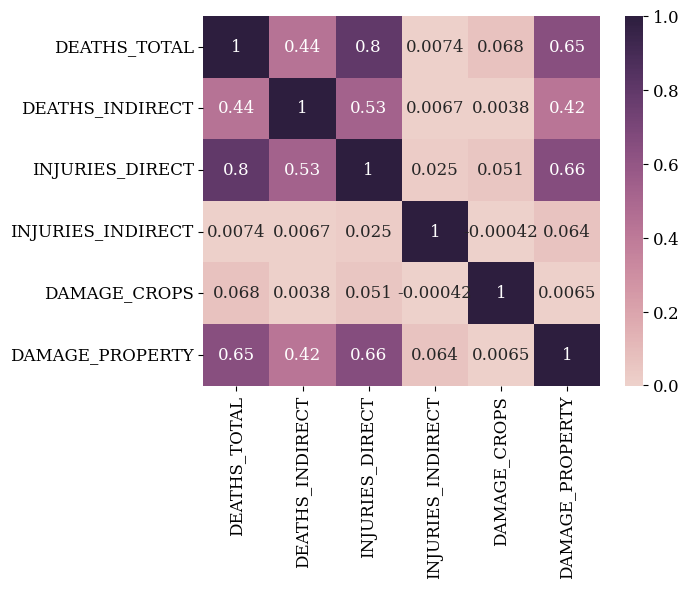

In [147]:
correlation = targets.corr()

plt.figure(facecolor='w')
sns.heatmap(correlation,cmap=sns.cubehelix_palette(as_cmap=True),annot=True)

In [148]:
#As a sanity check let's ensure all of these are the same size
print(len(features), len(targets))

# Scaling  -- do we need this?
# from sklearn import preprocessing
# scaler = preprocessing.StandardScaler().fit(features)
# scaled_spectra = scaler.transform(features)

from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor()
CV=KFold(shuffle = True, n_splits = 5, random_state=10) 
scores_models = cross_validate(forest_model, features, targets, cv = CV, return_train_score=True, scoring='r2') #

targets_pred = cross_val_predict(forest_model, features, targets, cv = CV)

scores = []
for i in range(5):
    scores.append(cross_validate(forest_model,features,
                                 targets[targets.columns[i]], 
                                 cv = KFold(n_splits=5, shuffle=True, random_state=10), 
                                 return_train_score=True, scoring = 'r2'))

26069 26069


KeyboardInterrupt: 

In [ ]:
scores

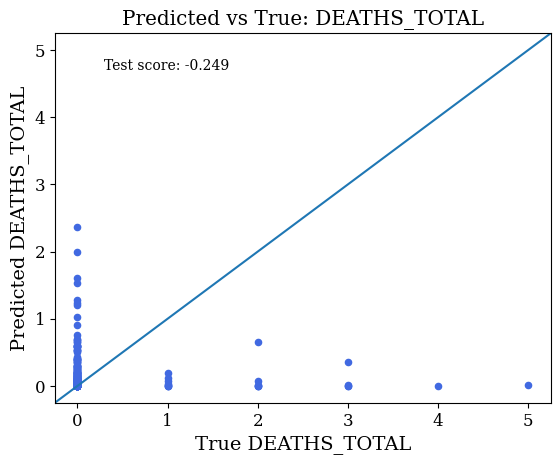

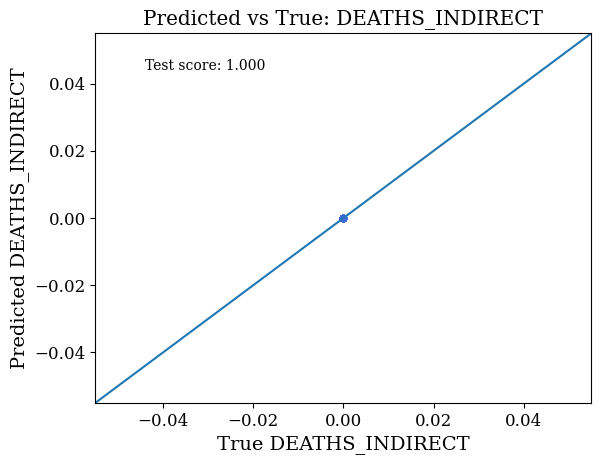

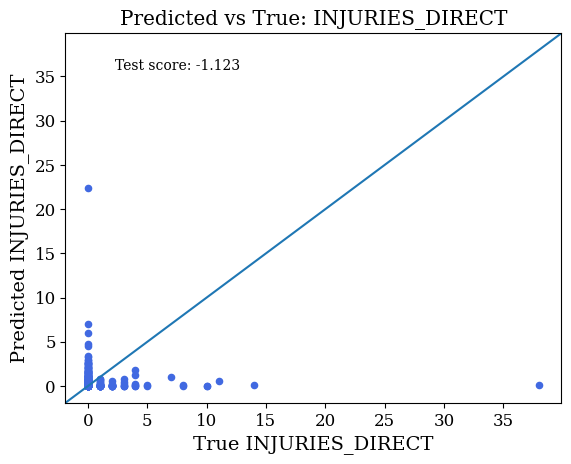

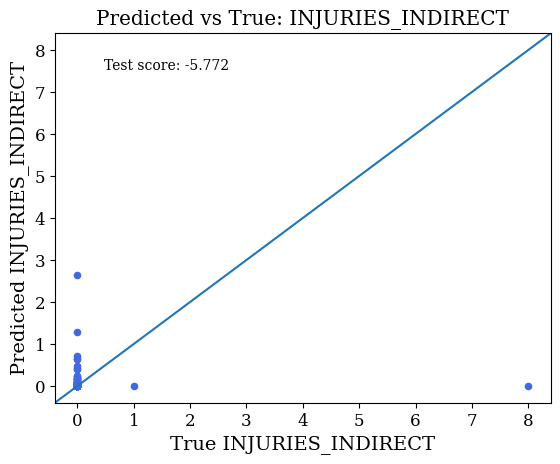

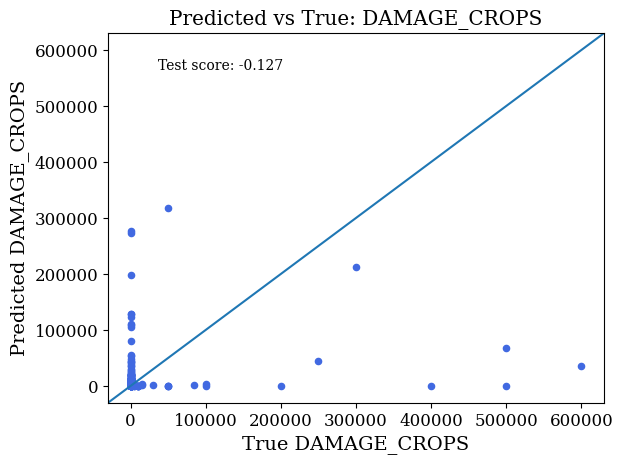

In [147]:
for i in range(5):
    plt.figure()
    plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes)
    plt.scatter(targets[targets.columns[i]],targets_pred[:,i], s = 20, c = 'royalblue')
    plt.xlabel('True ' + targets.columns[i], fontsize=14)
    plt.ylabel('Predicted ' + targets.columns[i],fontsize=14)
    #plt.axis('square')
    plt.text(0.1, .9, 'Test score: ' + str("{:.3f}".format(np.mean(scores[i]['test_score']))), fontsize = 10, transform=plt.gca().transAxes)
    #plt.xscale('log')
    #plt.yscale('log')
    lower = min(plt.xlim()[0], plt.ylim()[0])
    upper = max(plt.xlim()[1], plt.ylim()[1])
    plt.title("Predicted vs True: " + targets.columns[i])
    plt.xlim(lower,upper)
    plt.ylim(lower, upper)

In [142]:
# https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_roc_curve_visualization_api.html
from sklearn.metrics import RocCurveDisplay

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, targets, random_state=42, test_size=0.3)


from sklearn.metrics import roc_curve, auc


forest_model.fit(X_train, y_train)

y_pred_continuous = forest_model.predict(X_test)

evaluation_threshold = 0.0 
y_test_binary = (y_test > evaluation_threshold).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_continuous)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve using Random Forest Regressor Outputs')
plt.legend(loc="lower right")
plt.show()

ValueError: multilabel-indicator format is not supported

In [146]:
X = pd.DataFrame({
    'BEGIN_LAT': data_f['BEGIN_LAT'],
    #'BEGIN_LON': data_f['BEGIN_LON'],
    'INJURIES_TOT': data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']
})

pca = PCA(n_components = 2)
## Fit the data
pca.fit(X)

pca.components_

array([[-0.01369714,  0.99990619],
       [ 0.99990619,  0.01369714]])

In [147]:
pca.explained_variance_

array([103.41274254,  23.59686533])

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_148718/1099978459.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('BEGIN LAT [$^{\circ}$]')


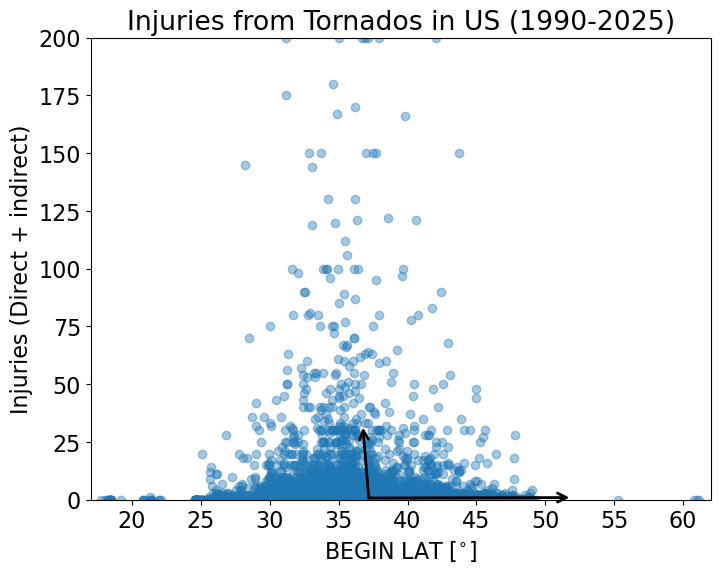

In [148]:
## This function will draw a vector in 2D
## given its components
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, 
                    shrinkB=0,
                    color="black")
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.figure(figsize=(8,6))
plt.scatter(data_f['BEGIN_LAT'], 
            data_f['INJURIES_DIRECT']+data_f['INJURIES_INDIRECT'], alpha=.4)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
    
plt.xlabel('BEGIN LAT [$^{\circ}$]')
plt.ylabel('Injuries (Direct + indirect)')
plt.title('Injuries from Tornados in US (1990-2025)')

plt.xlim([17,62])
plt.ylim([0,200])
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_148718/3339186993.py:33: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('BEGIN LON [$^{\circ}$]')


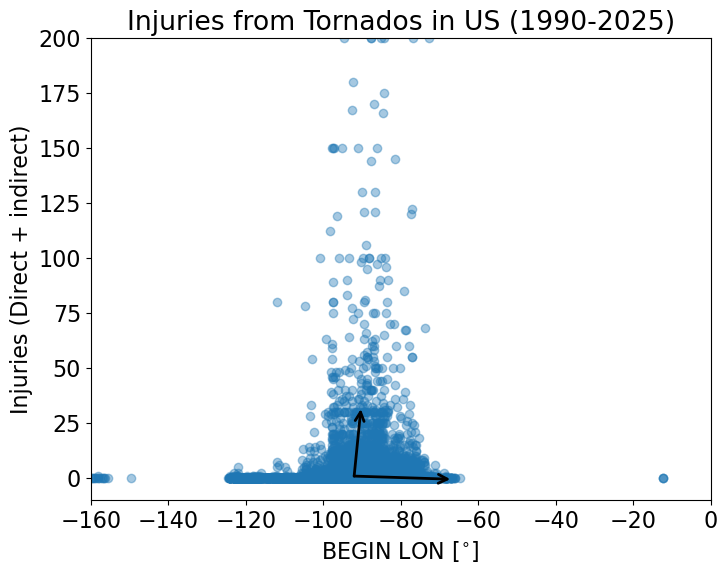

In [149]:
Xlon = pd.DataFrame({
    'BEGIN_LON': data_f['BEGIN_LON'],
    'INJURIES_TOT': data_f['INJURIES_DIRECT'] + data_f['INJURIES_INDIRECT']
})

pca = PCA(n_components = 2)
## Fit the data
pca.fit(Xlon)

pca.components_

## This function will draw a vector in 2D
## given its components
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, 
                    shrinkB=0,
                    color="black")
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.figure(figsize=(8,6))
plt.scatter(data_f['BEGIN_LON'], 
            data_f['INJURIES_DIRECT']+data_f['INJURIES_INDIRECT'], alpha=.4)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
    
    
plt.xlabel('BEGIN LON [$^{\circ}$]')
plt.ylabel('Injuries (Direct + indirect)')
plt.title('Injuries from Tornados in US (1990-2025)')

plt.xlim([-160,0])
plt.ylim([-10,200])
plt.show()

In [151]:
# import matplotlib.pyplot as plt

# # unused but required import for doing 3d projections with matplotlib < 3.2
# import mpl_toolkits.mplot3d  # noqa: F401

# from sklearn.decomposition import PCA

# fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# X_reduced = PCA(n_components=2).fit_transform(X)
# scatter = ax.scatter(
#     X_reduced[:, 0],
#     X_reduced[:, 1],
#     X_reduced[:, 2],
#     c=['BEGIN_LAT', 'BEGIN_LON', 'INJURIES'],
#     s=40,
# )

# ax.set(
#     title="First three principal components",
#     xlabel="1st Principal Component",
#     ylabel="2nd Principal Component",
#     zlabel="3rd Principal Component",
# )
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])
# ax.zaxis.set_ticklabels([])

# # Add a legend
# legend1 = ax.legend(
#     scatter.legend_elements()[0],
#     iris.target_names.tolist(),
#     loc="upper right",
#     title="Classes",
# )
# ax.add_artist(legend1)

# plt.show()